# 10 — Low-pass filters (`math`, SciPy, PyTorch, python-control)

**Baseline:** python-control transfer functions, Bode plots, and `forced_response`.

The plant is a first-order lag

$$
H(s) = \frac{1}{\tau s + 1}, \qquad \tau = \frac{1}{2\pi f_c}
$$

which is an RC (or analog) low-pass with cutoff \(f_c\). We drive it with the square wave from notebook `00` so the missing harmonics are obvious.

Four implementations of the *same* filter:

| Stack | What it actually computes |
| --- | --- |
| python-control | continuous \(H(s)\), then discrete-time forced response |
| `math` | explicit first-order IIR difference equation |
| SciPy | bilinear `butter` + `lfilter` |
| PyTorch | the same IIR recurrence on a CUDA tensor |


In [1]:
from __future__ import annotations

import math

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda


In [2]:
FS_HZ = 8_192
DURATION_S = 0.08
F0_HZ = 220.0
FC_HZ = 80.0                 # cutoff well below the square-wave fundamental
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
TAU = 1.0 / (2.0 * math.pi * FC_HZ)

t = np.arange(N, dtype=np.float64) / FS_HZ
u = signal.square(2.0 * np.pi * F0_HZ * t)   # excitation (SciPy, matches notebook 00)

print(f"tau = {TAU*1e3:.3f} ms   fc = {FC_HZ} Hz   f0 = {F0_HZ} Hz")


tau = 1.989 ms   fc = 80.0 Hz   f0 = 220.0 Hz


## python-control — continuous plant, forced response

This is the reference trajectory. `forced_response` integrates \( \dot{x} = Ax + Bu \) against the sampled input.


<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  --------------
  0.001989 s + 1


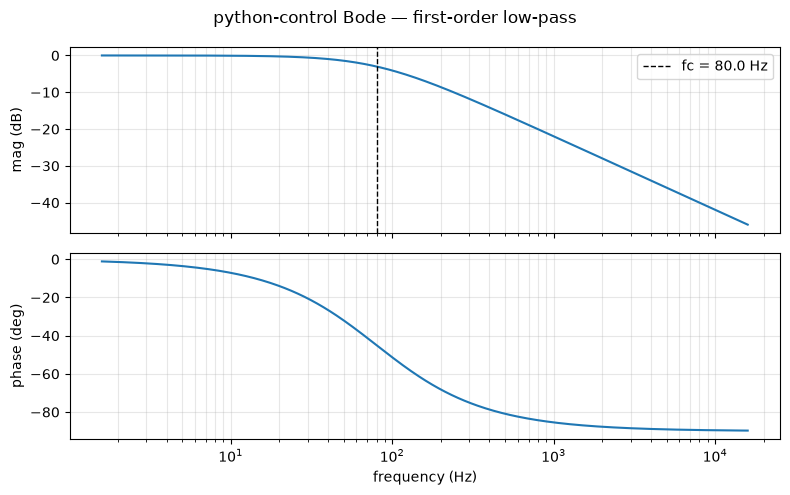

In [3]:
sys_lp = ct.tf([1.0], [TAU, 1.0])
print(sys_lp)

t_ct, y_ct = ct.forced_response(sys_lp, T=t, U=u)

mag, phase, omega = ct.frequency_response(sys_lp, omega=np.logspace(1, 5, 400))
# frequency_response returns FrequencyResponseData in recent python-control
if hasattr(mag, "magnitude"):
    w = np.asarray(mag.frequency).reshape(-1)
    m = np.asarray(mag.magnitude).reshape(-1)
    p = np.asarray(mag.phase).reshape(-1)
else:
    w = np.asarray(omega).reshape(-1)
    m = np.asarray(mag).reshape(-1)
    p = np.asarray(phase).reshape(-1)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
axes[0].axvline(FC_HZ, color="k", ls="--", lw=1, label=f"fc = {FC_HZ} Hz")
axes[0].set_ylabel("mag (dB)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()
axes[1].semilogx(w / (2 * np.pi), np.degrees(p))
axes[1].set_ylabel("phase (deg)")
axes[1].set_xlabel("frequency (Hz)")
axes[1].grid(True, which="both", alpha=0.3)
fig.suptitle("python-control Bode — first-order low-pass")
fig.tight_layout()
plt.show()


## `math` — forward-Euler IIR

From \( \tau \dot{y} + y = u \) with \( \dot{y} \approx (y[n] - y[n-1])/\Delta t \):

$$
y[n] = \alpha\, u[n] + (1 - \alpha)\, y[n-1], \qquad \alpha = \frac{\Delta t}{\tau + \Delta t}.
$$


In [4]:
def math_lowpass(u_list: list[float], dt: float, tau: float) -> list[float]:
    alpha = dt / (tau + dt)
    y = 0.0
    out = []
    for un in u_list:
        y = alpha * un + (1.0 - alpha) * y
        out.append(y)
    return out


y_math = math_lowpass(u.tolist(), DT, TAU)
print(f"alpha = {DT / (TAU + DT):.6f}   last y = {y_math[-1]:.4f}")


alpha = 0.057812   last y = 0.2406


## SciPy — bilinear Butterworth (order 1 matches the analog lag)


In [5]:
b_sp, a_sp = signal.butter(N=1, Wn=FC_HZ, btype="low", fs=FS_HZ, analog=False)
y_sp = signal.lfilter(b_sp, a_sp, u)
print("b =", b_sp)
print("a =", a_sp)


b = [0.02977546 0.02977546]
a = [ 1.         -0.94044908]


## PyTorch — same recurrence, on GPU

The recurrence is sequential in time so it will not fill a GPU, but the *state and input live on device* and the arithmetic is CUDA kernels. For long batches of independent channels this becomes a real win; here we keep one channel so it stays comparable.


In [6]:
def torch_lowpass(u_t: torch.Tensor, dt: float, tau: float) -> torch.Tensor:
    alpha = dt / (tau + dt)
    y = torch.zeros((), device=u_t.device, dtype=u_t.dtype)
    out = torch.empty_like(u_t)
    for i in range(u_t.numel()):
        y = alpha * u_t[i] + (1.0 - alpha) * y
        out[i] = y
    return out


u_th = torch.as_tensor(u, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
y_th = torch_lowpass(u_th, DT, TAU)
if device.type == "cuda":
    torch.cuda.synchronize()
y_gpu = y_th.detach().cpu().numpy()
print(y_th.device, float(y_th[-1]))


cuda:0 0.24063657224178314


## Compare time responses


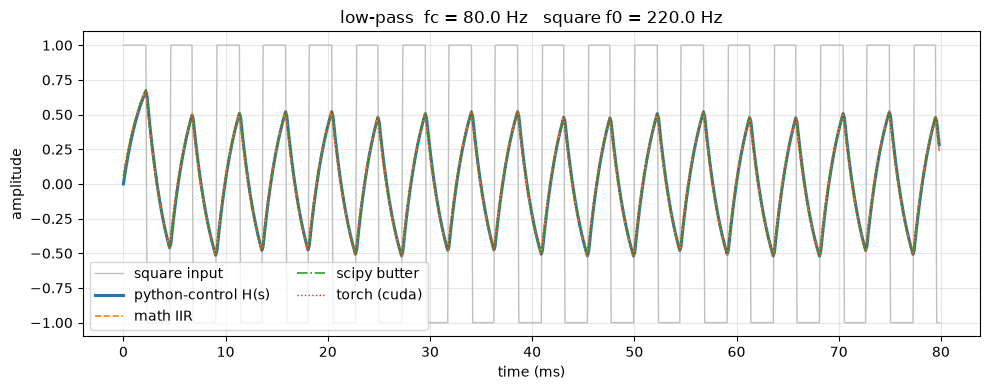

control vs math   5.784e-02
control vs scipy  2.978e-02
math vs torch     1.198e-07


In [7]:
ms = t * 1e3
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ms, u, color="0.75", lw=1.0, label="square input")
ax.plot(ms, y_ct, lw=2.2, label="python-control H(s)")
ax.plot(ms, y_math, lw=1.2, ls="--", label="math IIR")
ax.plot(ms, y_sp, lw=1.2, ls="-.", label="scipy butter")
ax.plot(ms, y_gpu, lw=1.0, ls=":", label=f"torch ({device})")
ax.set_xlabel("time (ms)")
ax.set_ylabel("amplitude")
ax.set_title(f"low-pass  fc = {FC_HZ} Hz   square f0 = {F0_HZ} Hz")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

def max_abs(a, b):
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))

print(f"control vs math   {max_abs(y_ct, y_math):.3e}")
print(f"control vs scipy  {max_abs(y_ct, y_sp):.3e}")
print(f"math vs torch     {max_abs(y_math, y_gpu):.3e}")


## Vectorized PyTorch FIR low-pass (this *does* use the GPU well)

A truncated sinc / Hamming window is a linear-phase FIR. `conv1d` is a single batched CUDA kernel.


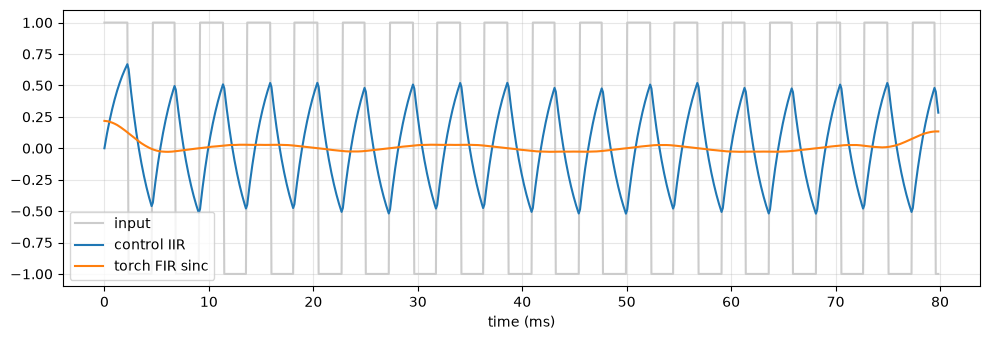

In [8]:
def torch_fir_lowpass(u_t: torch.Tensor, fc: float, fs: float, taps: int = 129) -> torch.Tensor:
    if taps % 2 == 0:
        raise ValueError("use an odd tap count so the peak sits on a sample")
    n = torch.arange(taps, device=u_t.device, dtype=u_t.dtype) - (taps - 1) / 2
    fc_n = fc / fs
    h = 2 * fc_n * torch.sinc(2 * fc_n * n)
    window = torch.hamming_window(taps, periodic=False, device=u_t.device, dtype=u_t.dtype)
    h = h * window
    h = h / h.sum()
    x = u_t.view(1, 1, -1)
    k = h.view(1, 1, -1)
    pad = taps // 2
    return torch.nn.functional.conv1d(x, k, padding=pad).view(-1)


y_fir = torch_fir_lowpass(u_th, FC_HZ, FS_HZ).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(ms, u, color="0.8", label="input")
ax.plot(ms, y_ct, label="control IIR")
ax.plot(ms, y_fir, label="torch FIR sinc")
ax.set_xlabel("time (ms)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## Takeaways

- python-control is the spec: write \(H(s)\), inspect Bode, then simulate.
- The `math` Euler IIR tracks that spec closely at this sample rate (\(f_s \gg f_c\)).
- SciPy's bilinear Butterworth is a *different* discretization — close, not bit-identical.
- Use a sequential IIR on GPU only when you have many parallel channels; use `conv1d` FIR when you want occupancy.
- Notebook `11` repeats the pattern for a band-pass.
